In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
K = 100
premium = 5
S = np.linspace(50, 150, 201)

payoff = np.maximum(S-K, 0)
profit = payoff - premium

print("P&L at lowest price:", profit[0])    
print("P&L at highest price:", profit[-1]) 

P&L at lowest price: -5.0
P&L at highest price: 45.0


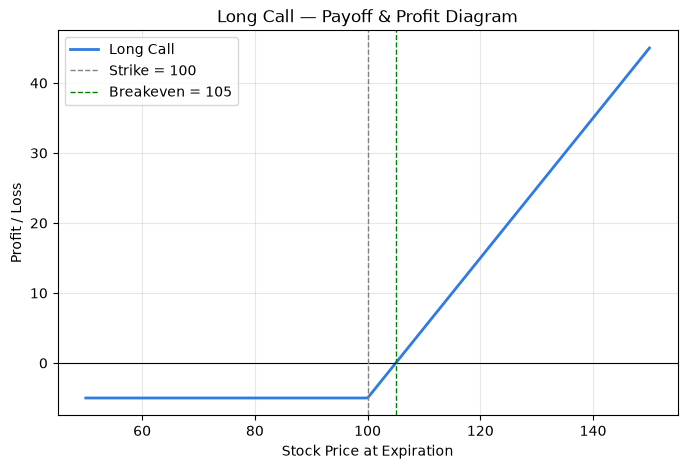

In [12]:
breakeven = K + premium

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(S, profit, color="#2f7be0", linewidth=2, label="Long Call")
ax.axhline(0, color="black", linewidth=0.8) 
ax.axvline(K, color="gray", linestyle="--", linewidth=1, label=f"Strike = {K}")
ax.axvline(breakeven, color="green", linestyle="--", linewidth=1, label=f"Breakeven = {breakeven}")


ax.set_title("Long Call — Payoff & Profit Diagram")
ax.set_xlabel("Stock Price at Expiration")
ax.set_ylabel("Profit / Loss")                          
ax.legend()
ax.grid(True, alpha=0.3)
plt.show() 

In [13]:
def option_payoff(S, K, option_type):
    """Payoff at expiration for the option holder (long side)."""
    if option_type == "call":
        return np.maximum(S - K, 0)
    elif option_type == "put":
        return np.maximum(K - S, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

def option_profit(S, K, premium, option_type, position):
    """P&L including premium. position = 'long' or 'short'."""
    payoff = option_payoff(S, K, option_type)
    if position == "long":
        return payoff - premium      # long pays the premium
    elif position == "short":
        return premium - payoff      # short receives the premium
    else:
        raise ValueError("position must be 'long' or 'short'")

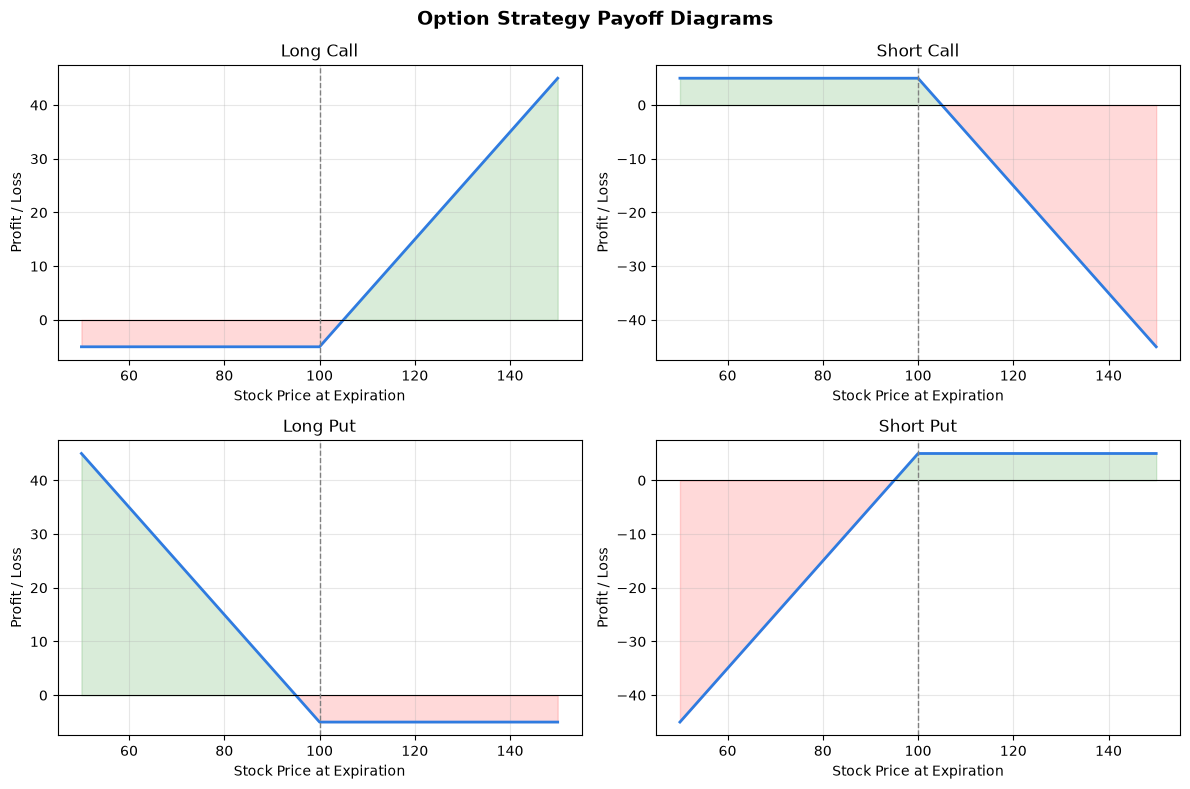

In [14]:
# Cell 5: 2x2 grid of the four basic option positions
K = 100
premium = 5
S = np.linspace(50, 150, 201)

positions = [("long", "call"), ("short", "call"),
             ("long", "put"),  ("short", "put")]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (position, option_type) in zip(axes.flat, positions):
    profit = option_profit(S, K, premium, option_type, position)
    ax.plot(S, profit, color="#2f7be0", linewidth=2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(K, color="gray", linestyle="--", linewidth=1)
    ax.fill_between(S, profit, 0, where=(profit > 0), color="green", alpha=0.15)
    ax.fill_between(S, profit, 0, where=(profit < 0), color="red", alpha=0.15)
    ax.set_title(f"{position.capitalize()} {option_type.capitalize()}")
    ax.set_xlabel("Stock Price at Expiration")
    ax.set_ylabel("Profit / Loss")
    ax.grid(True, alpha=0.3)

fig.suptitle("Option Strategy Payoff Diagrams", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()